In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../heart_disease_raw/heart.csv')
print(df.shape)
df.head()

(214, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       214 non-null    int64  
 1   sex       214 non-null    int64  
 2   cp        214 non-null    int64  
 3   trestbps  214 non-null    int64  
 4   chol      214 non-null    int64  
 5   fbs       214 non-null    int64  
 6   restecg   214 non-null    int64  
 7   thalach   214 non-null    int64  
 8   exang     214 non-null    int64  
 9   oldpeak   214 non-null    float64
 10  slope     214 non-null    int64  
 11  ca        214 non-null    int64  
 12  thal      214 non-null    int64  
 13  target    214 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 23.5 KB
None


              age         sex          cp    trestbps        chol         fbs  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean    56.485981    0.682243    0.925234  133.429907  251.24

In [4]:
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


In [5]:
print(f"Jumlah duplikat: {df.duplicated().sum()}")

Jumlah duplikat: 24


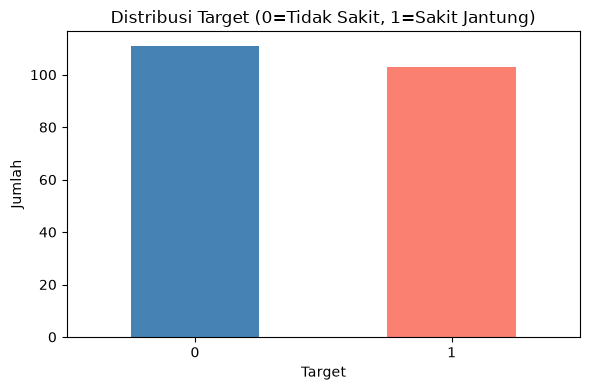

In [6]:
plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribusi Target (0=Tidak Sakit, 1=Sakit Jantung)')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

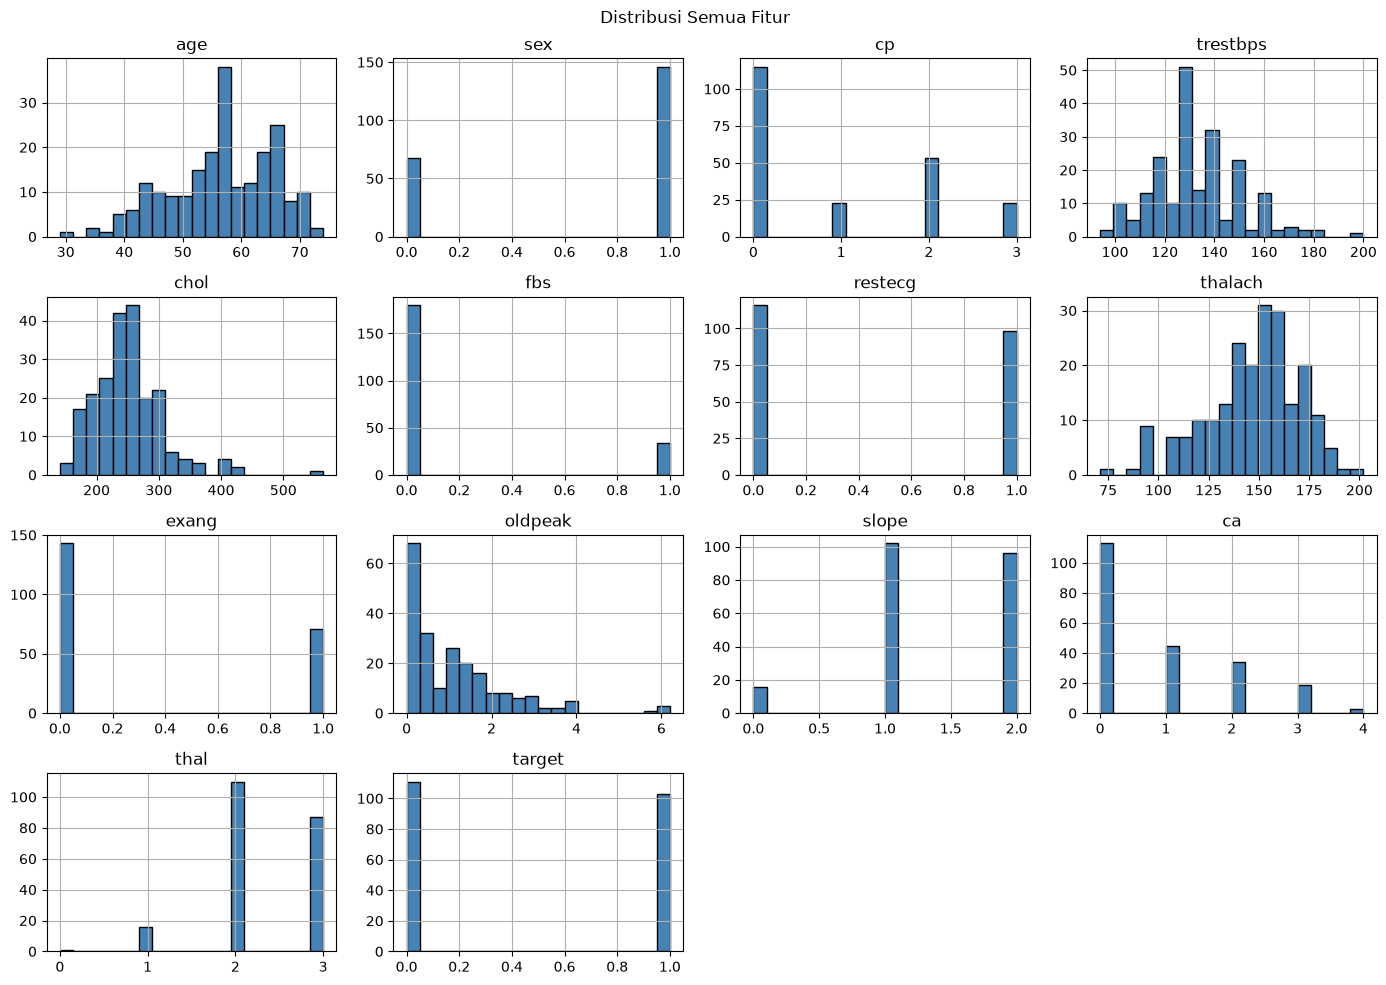

In [7]:
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Semua Fitur')
plt.tight_layout()
plt.show()

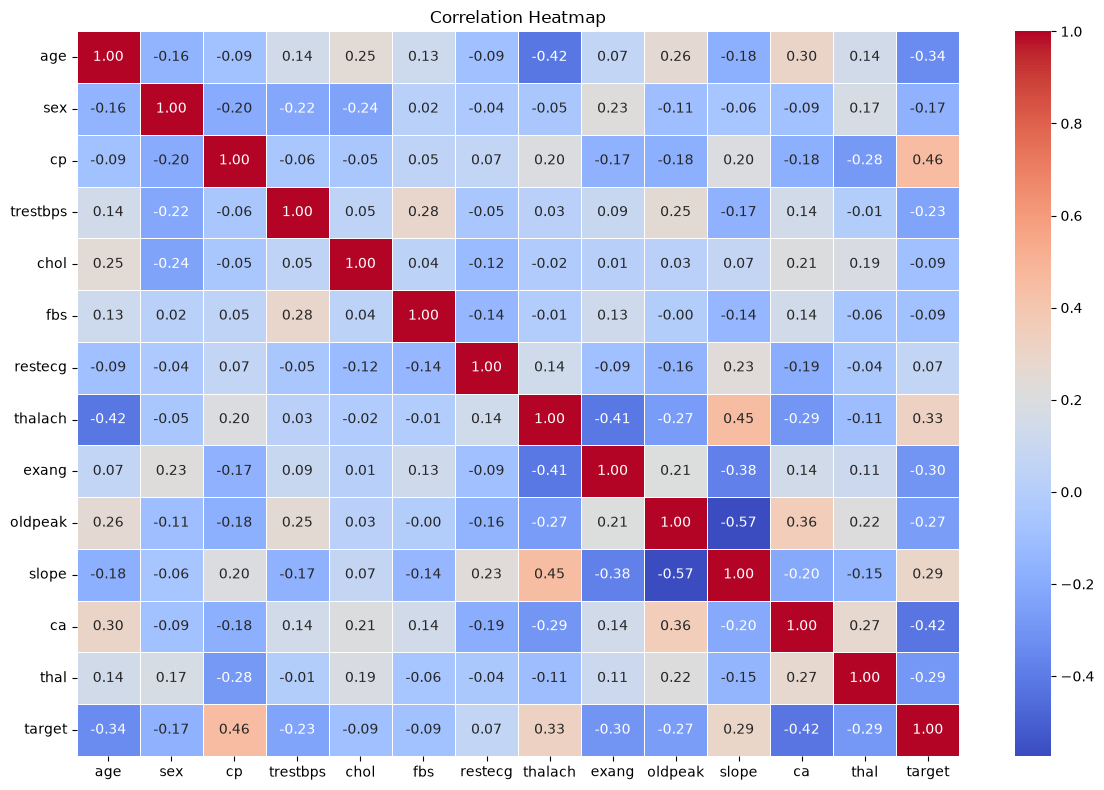

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

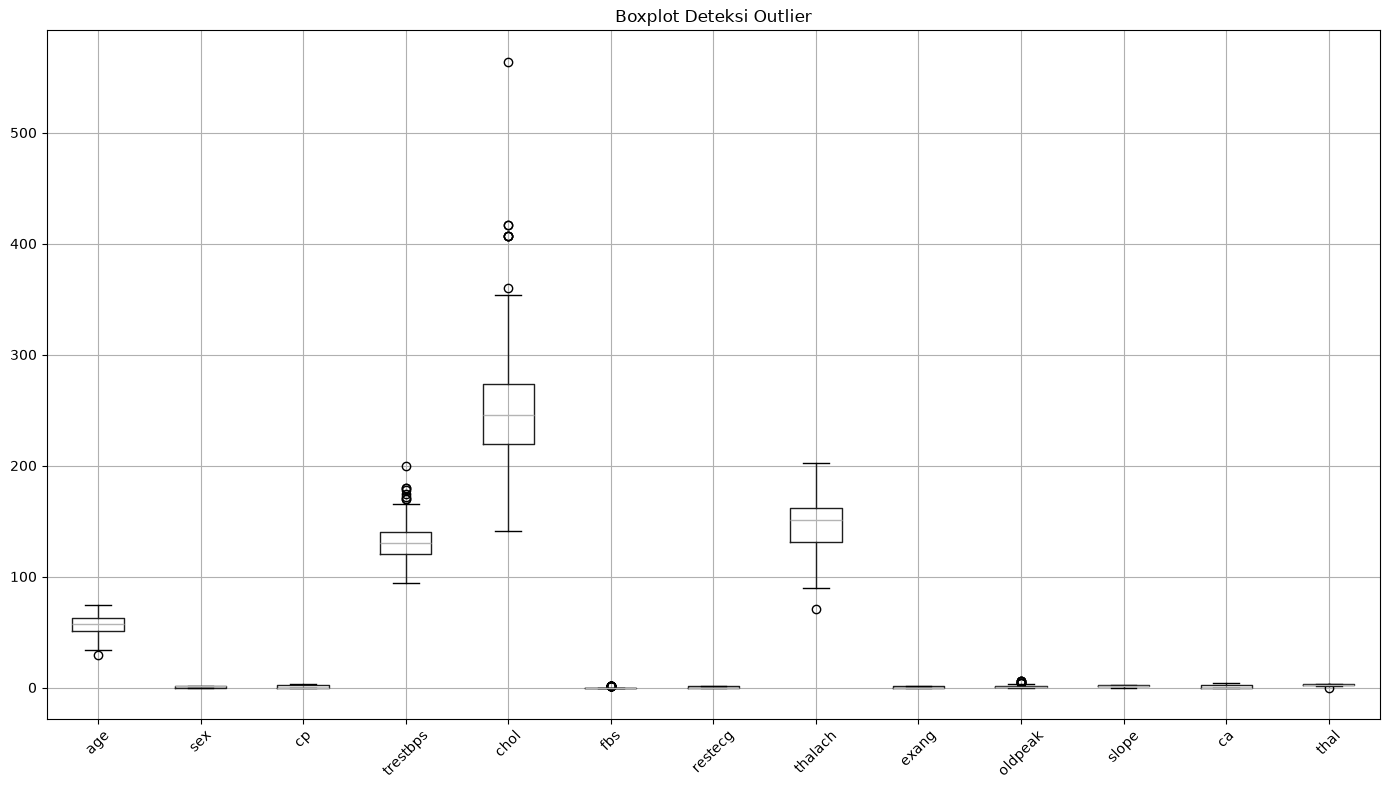

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('target')

plt.figure(figsize=(14, 8))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot Deteksi Outlier')
plt.tight_layout()
plt.show()

In [10]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print(f"Shape setelah cleaning: {df_clean.shape}")

Shape setelah cleaning: (190, 14)


In [11]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

df_preprocessed = X_scaled.copy()
df_preprocessed['target'] = y.values

print("Shape final:", df_preprocessed.shape)
df_preprocessed.head()

Shape final: (190, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.765597,0.687654,1.766905,0.716750,-0.297857,0.0,-0.948683,0.090561,-0.695971,1.299817,-2.224923,-0.791118,-2.077035,1
1,-2.112402,0.687654,0.869279,-0.149184,0.064730,0.0,1.054093,1.684161,-0.695971,2.496015,-2.224923,-0.791118,-0.449667,1
2,-1.669633,-1.454219,-0.028346,-0.149184,-0.916387,0.0,-0.948683,1.038107,-0.695971,0.402668,0.941634,-0.791118,-0.449667,1
3,-0.009249,0.687654,-0.028346,-0.726472,-0.233871,0.0,1.054093,1.296528,-0.695971,-0.195432,0.941634,-0.791118,-0.449667,1
4,0.101444,-1.454219,-0.925972,-0.726472,2.282906,0.0,1.054093,0.650474,1.436842,-0.394798,0.941634,-0.791118,-0.449667,1


In [12]:
os.makedirs('heart_disease_preprocessing', exist_ok=True)
df_preprocessed.to_csv('heart_disease_preprocessing/heart_preprocessed.csv', index=False)
print("Dataset berhasil disimpan!")
print(df_preprocessed.shape)

Dataset berhasil disimpan!
(190, 14)
